- This notebook assumes you have went through the **Decision Tree** notebook as it is relevant to Gradient Boost.
- Watch AssemblyAI's from scratch series: [AssemblyAI's video](https://www.youtube.com/watch?v=p1hGz0w_OCo&list=PLcWfeUsAys2k_xub3mHks85sBHZvg24Jd) or [Github repo](https://github.com/AssemblyAI-Community/Machine-Learning-From-Scratch)
- Some of the long explanation words are generated with 2.5 Flash, to give extra clarity or example which is believed to help understanding even further.

In [1]:
# Install huggingface's dataset module
!pip install datasets

# Install data analysis module
!pip install statsmodels

# Instal plotting module
!pip install matplotlib
!pip install seaborn

In [2]:
import numpy as np
import pandas as pd 

# Hugging face
from datasets import load_dataset

# Sklearn modules
from sklearn.datasets import load_iris, load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree 
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import accuracy_score,classification_report, mean_squared_error, mean_absolute_error, r2_score
 
# Data analysis modules
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Plotter 
import matplotlib.pyplot as plt 

/home/troll/miniconda3/envs/random/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Lesson: Basic Understanding of AI terms

- This notebook is made in mind that the reader has little knowledge regarding AI.
- This mini section should be understood in depth before continuing.
- Important understanding:
    - `feature` is the "what" - Example: What characteristics of this house? 
        - Long version: "Feature" can be Data points or characteristics of an object that help you describe it. They are **independent variables** in your dataset.
    - `label` is the "answer" - Example: What is its price. 
        - Long version: "Label" is the **Outcome** you are trying to predict. It is a dependent variable. 
    - Regression task.
        - A regression task predicts a continuous numerical value. The goal is to model the relationship between input features and a continuous output, allowing for a prediction within a range.
        - Output: A real number.
        - Examples: Predicting a house price (e.g., $450,000), a person's age (e.g., 34.5 years), or the temperature tomorrow (e.g., 22°C).
    - Classification task.
        - A classification task predicts a discrete category or class label. The goal is to sort data into predefined groups.
        - Output: A category.
        - Examples: Determining if an email is spam or not spam (binary classification), classifying a fruit as an apple, orange, or banana (multi-class classification), or identifying if a customer will churn or not churn.
- What is Mean Square Error (MSE)? 
    - TL;DR. For Regression Task. 
    - In decision tree, MSE is a splitting criterion used in regression decision trees. Regression trees are used to predict a continuous numerical value, like house prices or a person's age.
    - The goal is to choose the split that results in the lowest weighted average MSE for the child nodes. 
    - A lower MSE indicates that the data points within a node are closer to their mean, meaning the node is more "pure" in terms of its target values; **The lower the MSE, the better (closer to target)**.
        - At each step of building the tree, the algorithm considers different possible splits for a node. 
        - For each potential split, it calculates the MSE of the resulting child nodes. 
        - The MSE of a node is the average of the squared differences between the actual values and the predicted mean value of that node.
    - $MSE= \frac{1}{n}\sum_{i=1}^n(y_i-\hat{y}_i)^2$
        - $n$ is the number of data points in the node.
        - $yi$​ is the actual value of the i-th data point; Actual or Target value.
        - $y^​i$​ is the predicted mean value for all data points in that node; Predicted Value.
- What is Cross-Entropy Loss?
    - TL;DR. For Classification.
    - Cross-entropy is a metric used in classification decision trees to measure the impurity of a node.
    - It quantifies the difference between the actual class distribution in a node and a perfect distribution where all data points belong to a single class. 
    - Cross-entropy measures the "surprise" of a model's prediction.
    - The goal of a decision tree algorithm is to find the best feature to split a node, and it does so by selecting the split that results in the greatest reduction in cross-entropy. 
    - This reduction is often referred to as **Information Gain**.
    - $Cross - Entropy = -\sum_{k=1}^Cp_klog_2(p_k)$
        - $p_k​$ is the proportion of data points belonging to class $k$ within the node.
- What is Gini impurity?
    - TL;DR. For Classification.
    - Gini impurity is a splitting criterion used in classification decision trees. 
        - These trees predict a categorical outcome, such as whether an email is spam or not, or if a customer will churn.
    - Gini impurity measures the "impurity" or disorder of a node. 
        - It quantifies the probability that a randomly chosen data point from the node would be incorrectly classified if you were to randomly assign a class label based on the class distribution in that node. 
        - A Gini impurity of 0 means the node is perfectly pure (all data points belong to the same class), while a higher value indicates a mix of classes; **Close to 0 = Pure**.
    - The decision tree algorithm calculates the Gini impurity for each potential split and chooses the split that leads to the **greatest reduction in impurity** (or the lowest weighted average Gini impurity for the child nodes).
    - $Gini=1-\sum_{i=1}^C(p^2_k)$
        - $p_k$​ is the proportion of data points belonging to class $k$ within the node.

More Information
- Cross-Entropy Loss vs Gini
    - **Computation**: Cross-entropy uses a _logarithm_, which is slightly more computationally intensive than Gini impurity's squaring operation.
    - **Maximum Value**: For a binary classification problem, Gini impurity has a maximum value of 0.5, while cross-entropy (or entropy) has a maximum of 1.
    - **Penalty**: Both metrics penalize impurity. Cross-entropy tends to penalize confident but incorrect predictions more heavily than Gini impurity.
- What happens if you use MSE on a classification task?
    - **Inappropriate Assumptions**: MSE assumes that the output values are continuous and have a Gaussian distribution, which is not the case for classification task where the outputs are distinct (or a percentage of; 90% dog, 10% cat).
    - **Weak Penalty for Misclassification**: MSE penalizes errors based on the squared distance between the predicted value and the target value. 
        - For classification, the target values are typically 0 or 1. If a model predicts a probability of 0.94 for a class that is actually 1, the MSE loss is a small (1−0.94)2=0.0036.
        - However, if it predicts 0.49 for the same class (which is technically a misclassification if the threshold is 0.5), the MSE is still small, (1−0.49)2=0.26.
    - **Non-Convexity**: The primary issue is that using MSE with a classification model like logistic regression can lead to a non-convex loss function. 
        - A non-convex function has multiple "dips" or local minima, making it difficult for optimization algorithms (like gradient descent) to find the best possible solution. 
        - The model can get stuck in a local minimum and fail to converge to the optimal set of parameters.

# Gradient Boost

- Used in regression and classification problems.

- Gradient boost is a **boosting** method.
    - It builds tree **sequentially**, 
    - with each new tree correcting the errors of previous ones. 
- The algorithm works by **iteratively minimize a loss function using <u>gradient descent</u>**.
    - This is to **reduce bias** 
    - and can result in a **single highly accurate model**.
- This makes it an incredibly effective optimization algorithm.
- _Cons_:
    -  _The reliance on previous trees makes Gradient Boosting_ 
        - _slower to train_
        - _more prone to overfitting_ 
        - _if not **properly regularized**_
    - _It also has **high tuning complexity**_
- Gradient boosting is the preferred algorithm when the ultimate goal is maximum predictive accuracy and you have the time and resources for careful tuning.

Technically, How it works:
- Start with an initial guess: Begin with a simple model, often a constant value, to make the first prediction.
- Calculate the residuals: The residual is the difference between the actual value and the predicted value. This residual is a measure of the error.
- Train a new model on the residuals: A new model (e.g., a decision tree) is trained to predict the residuals from the previous step. In essence, this new model is trying to correct the errors of the old model.
- Add the new model to the ensemble: The new model's predictions are added to the predictions of the existing models. This is done with a learning rate (also known as shrinkage), which is a small number (typically between 0 and 1) that controls how much each new model contributes. A small learning rate helps prevent overfitting.
- Repeat: Steps 2-4 are repeated for a specified number of iterations. Each new iteration adds a new model that further reduces the error of the entire ensemble.


# Gradient Boost for Classification

- Let's understand Decision Tree from Classification perspective first.
- We will use the [Iris dataset](https://huggingface.co/datasets/scikit-learn/iris) for a simplified study of Decision Tree.
- We will use the [Wine dataset](https://huggingface.co/datasets/lvwerra/red-wine) as a more complex dataset.

## 1. Iris Dataset (Simple)

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  

--- Classification Report (Model Trained on ALL Four Features) ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  v

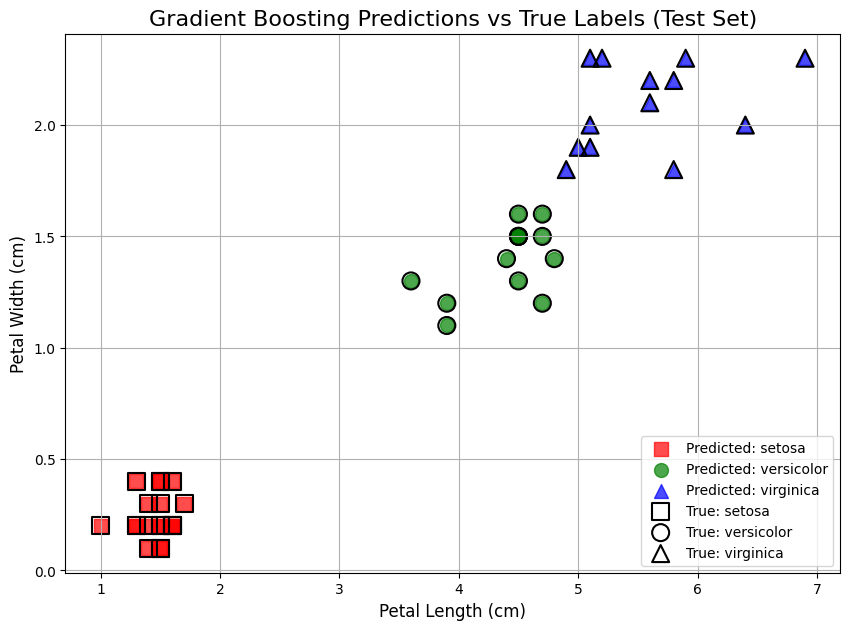

In [3]:
# --- Dataset setup ---
# We load the Iris dataset and use all four features for the model.
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# Create a DataFrame using the data and feature names
df = pd.DataFrame(data=iris.data, columns=iris.feature_names) 
print(df.describe())

# The features for visualization will be a subset of the full dataset
# We'll use petal length and petal width as they provide the best separation
X_plot = iris.data[:, 2:4]
feature_names_plot = ['petal length (cm)', 'petal width (cm)']

# Split the full dataset for training and testing the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Get the corresponding test data for plotting
X_test_plot = X_test[:, 2:4]

# --- Model Building ---
# Initialize and train a single Gradient Boosting model on all four features.
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbc.fit(X_train, y_train) 

# Make predictions on the test set (using all four features)
y_pred = gbc.predict(X_test)

# --- Print Classification Report ---
print("\n--- Classification Report (Model Trained on ALL Four Features) ---")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# --- Plot ---
# Create a figure and axes
fig, ax = plt.subplots(figsize=(10, 7))

# Define colors and markers for each class
colors = ['red', 'green', 'blue']
markers = ['s', 'o', '^']
class_labels = iris.target_names

# Plot the predicted classes with solid colors
for i, (target_name, color) in enumerate(zip(class_labels, colors)):
    ax.scatter(X_test_plot[y_pred == i, 0], X_test_plot[y_pred == i, 1],
               c=color, label=f'Predicted: {target_name}', marker=markers[i],
               s=100, alpha=0.7)

# Plot the true classes with outlines/different markers to compare
for i, (target_name, marker) in enumerate(zip(class_labels, markers)):
    ax.scatter(X_test_plot[y_test == i, 0], X_test_plot[y_test == i, 1],
               edgecolor='black', facecolors='none', marker=marker, s=150,
               linewidth=1.5, label=f'True: {target_name}')

# Add plot labels and title
ax.set_title('Gradient Boosting Predictions vs True Labels (Test Set)', fontsize=16)
ax.set_xlabel('Petal Length (cm)', fontsize=12)
ax.set_ylabel('Petal Width (cm)', fontsize=12)
ax.legend(loc='lower right')
ax.grid(True)
plt.show()

- Gradient Boost is an ensemble of many decision trees, sequentially. 
- In order to visualize, you need to specify **which tree to visualize**

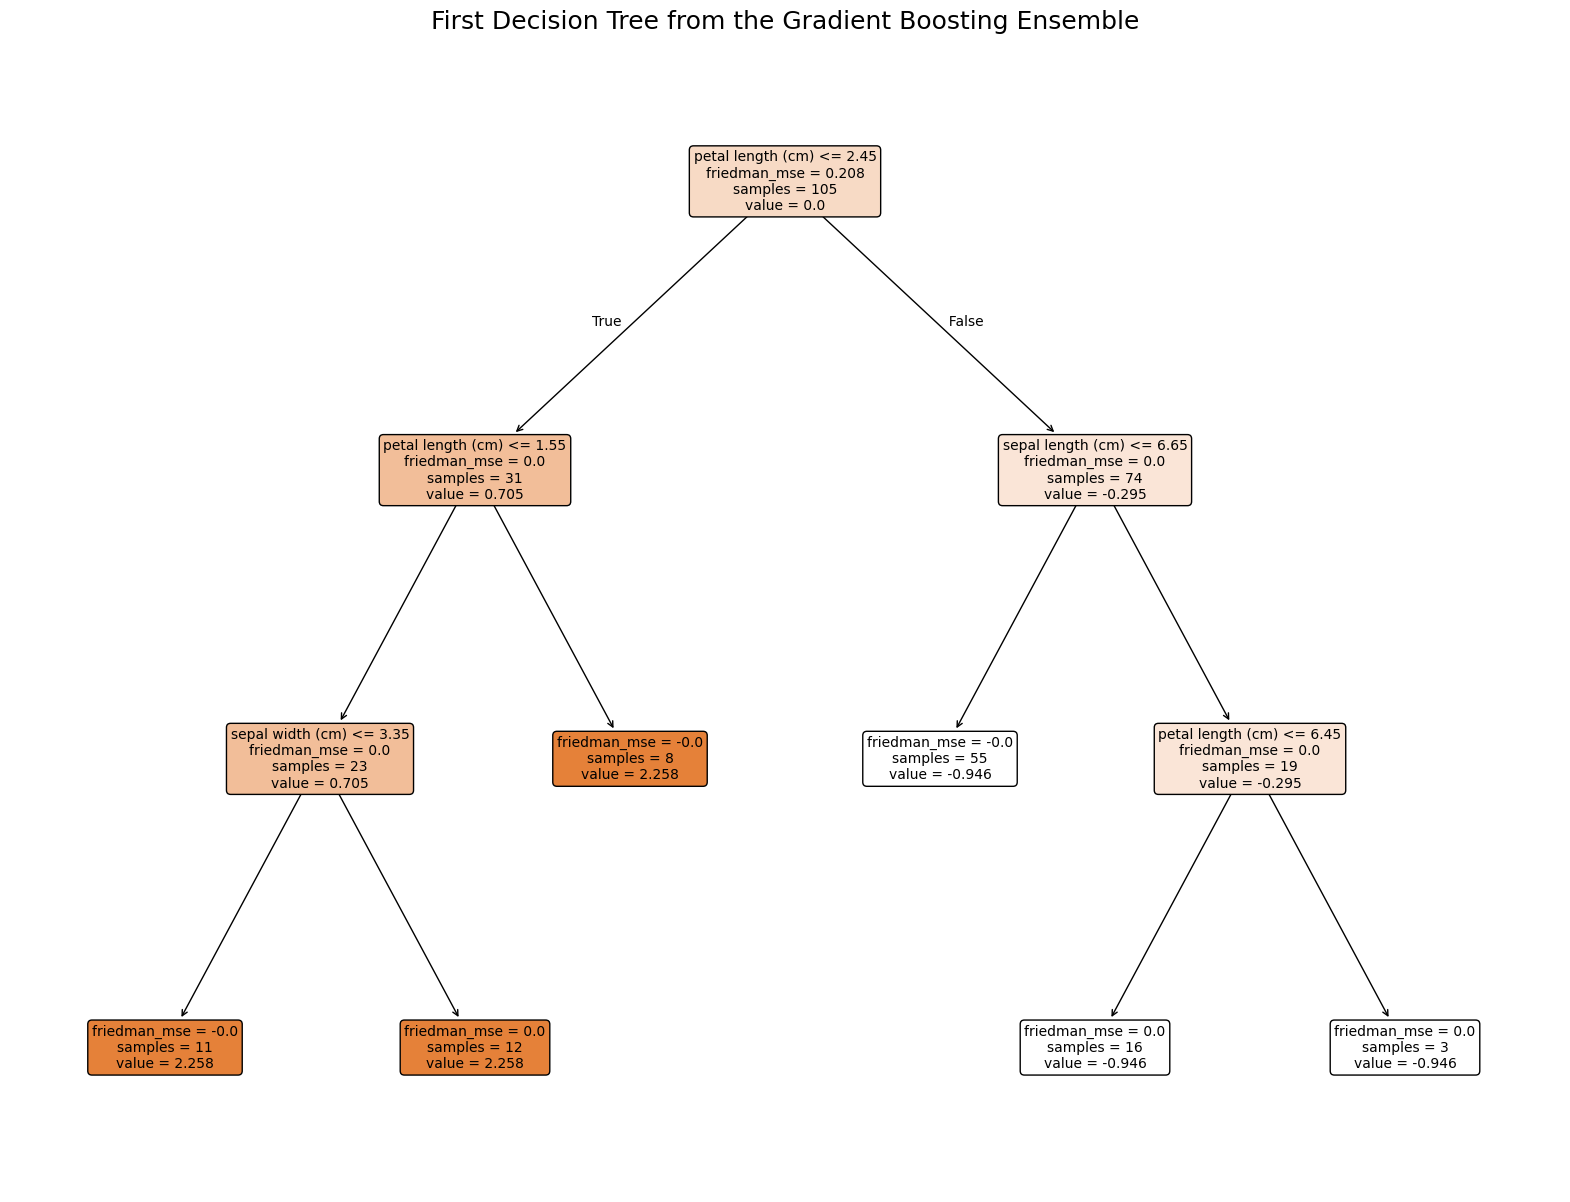

In [4]:
# Select the first tree for the first class (index 0), petal length
# The trees are stored in a 2D array (n_estimators, n_classes)
# In this case, gbc.estimators_[0, 0] is the first tree.
first_tree = gbc.estimators_[0, 0]

# Plot the selected tree
plt.figure(figsize=(20, 15))
plot_tree(
    first_tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("First Decision Tree from the Gradient Boosting Ensemble", fontsize=18)
plt.show()

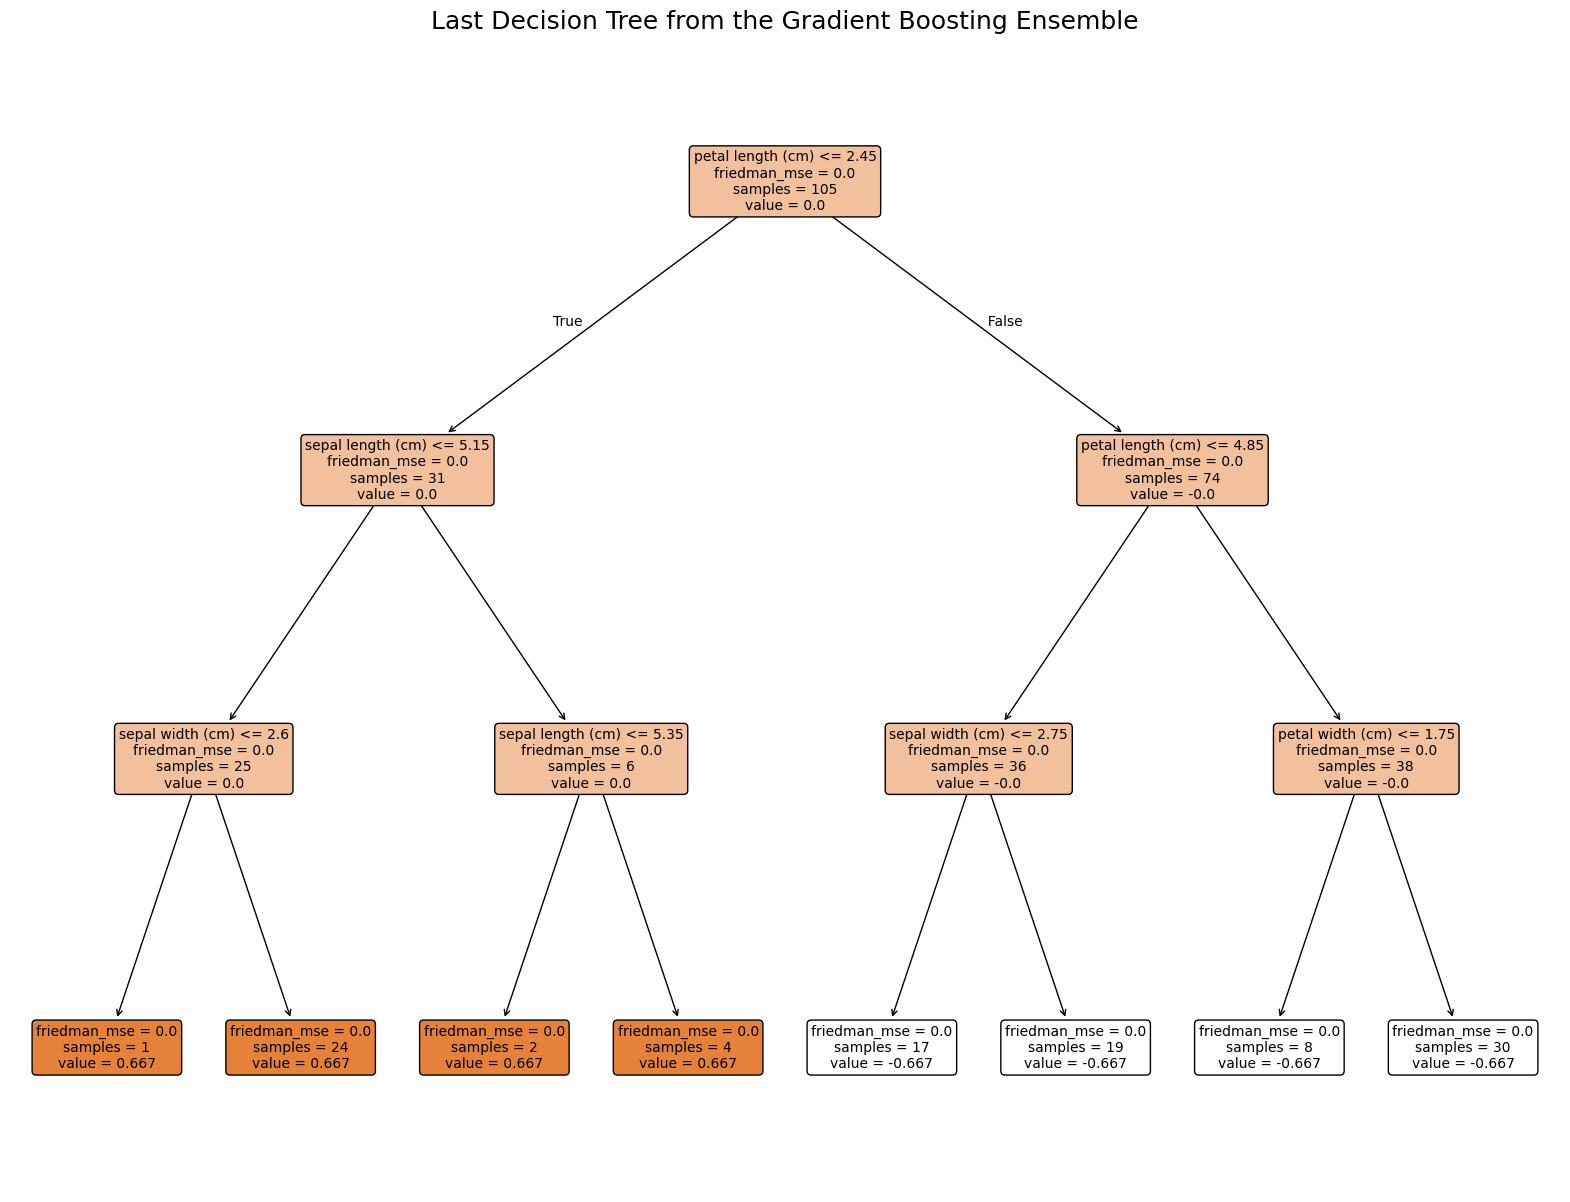

In [5]:
# Select the last tree for the first class (index 0), petal length
# The trees are stored in a 2D array (n_estimators, n_classes)
# In this case, gbc.estimators_[0, 0] is the first tree.
last_tree = gbc.estimators_[99, 0]

# Plot the selected tree
plt.figure(figsize=(20, 15))
plot_tree(
    last_tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Last Decision Tree from the Gradient Boosting Ensemble", fontsize=18)
plt.show()

### Note

- How it uses Friedman_MSE instead of Gini Impurity?
- This is because it is a **regression-based algorithm** that optimizes a loss function, not a classification-based one that optimizes node purity.
- _Why Gini Impurity does not apply to Gradient Boost_?
    - Decision Trees (DecisionTreeClassifier) for classification use criteria like Gini impurity or entropy to determine the best split. 
        - Their goal is to create homogeneous child nodes, and they measure this "purity" directly.
    - Gradient Boosting builds a series of regression trees, even for classification problems. 
        - The trees are trained to predict the negative gradient of the loss function from the previous stage of boosting. 
        - For classification, this loss function is typically deviance (or log loss). 
        - The split criterion for these regression trees is based on a **reduction in a measure of error**, not impurity.
- **The criterion Parameter**
    - The criterion parameter is for the regression trees within the ensemble. 
    - Its purpose is to **measure the quality of a split based on error**, not impurity. One can choose to use: 
        - 'friedman_mse' (default): Mean squared error with a special improvement score from Friedman.
        - 'squared_error': Standard mean squared error.
- Although Gradient Boost's core mechanism of minimizing a differentiable loss function makes it particularly well-suited for regression tasks, it is a highly versatile and powerful algorithm that performs well on both regression and classification tasks. 

--- 

## 2. Breast Cancer Dataset (sklearn) - Prebuild & Custom (From Scratch)

### Using sklearn's model

- On a fun side test, let's try using a single tree.
    - Knowing that the model is a regression, compare it to a specialized classifier model (from Decision Tree)
    - And compare its results

--- Model Accuracy per Iteration ---
Iteration 1: Validation Accuracy = 0.6404 | Test Accuracy = 0.6228
Iteration 2: Validation Accuracy = 0.6404 | Test Accuracy = 0.6228
Iteration 3: Validation Accuracy = 0.8860 | Test Accuracy = 0.8947
Iteration 4: Validation Accuracy = 0.8947 | Test Accuracy = 0.8860
Iteration 5: Validation Accuracy = 0.8860 | Test Accuracy = 0.9035
Iteration 6: Validation Accuracy = 0.8947 | Test Accuracy = 0.9123
Iteration 7: Validation Accuracy = 0.8772 | Test Accuracy = 0.9123
Iteration 8: Validation Accuracy = 0.8772 | Test Accuracy = 0.9123
Iteration 9: Validation Accuracy = 0.8772 | Test Accuracy = 0.9123
Iteration 10: Validation Accuracy = 0.8772 | Test Accuracy = 0.9123
Iteration 11: Validation Accuracy = 0.8860 | Test Accuracy = 0.9211
Iteration 12: Validation Accuracy = 0.8860 | Test Accuracy = 0.9123
Iteration 13: Validation Accuracy = 0.9035 | Test Accuracy = 0.9211
Iteration 14: Validation Accuracy = 0.8947 | Test Accuracy = 0.9298
Iteration 15: Valida

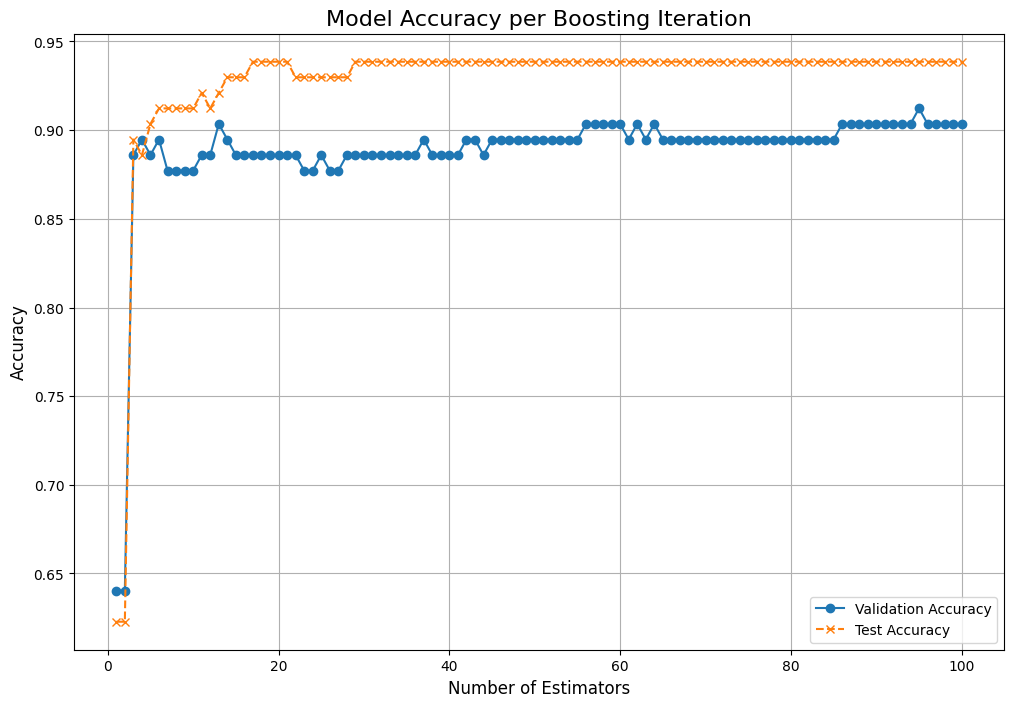


Final Validation Accuracy: 0.90
Final Test Accuracy: 0.94


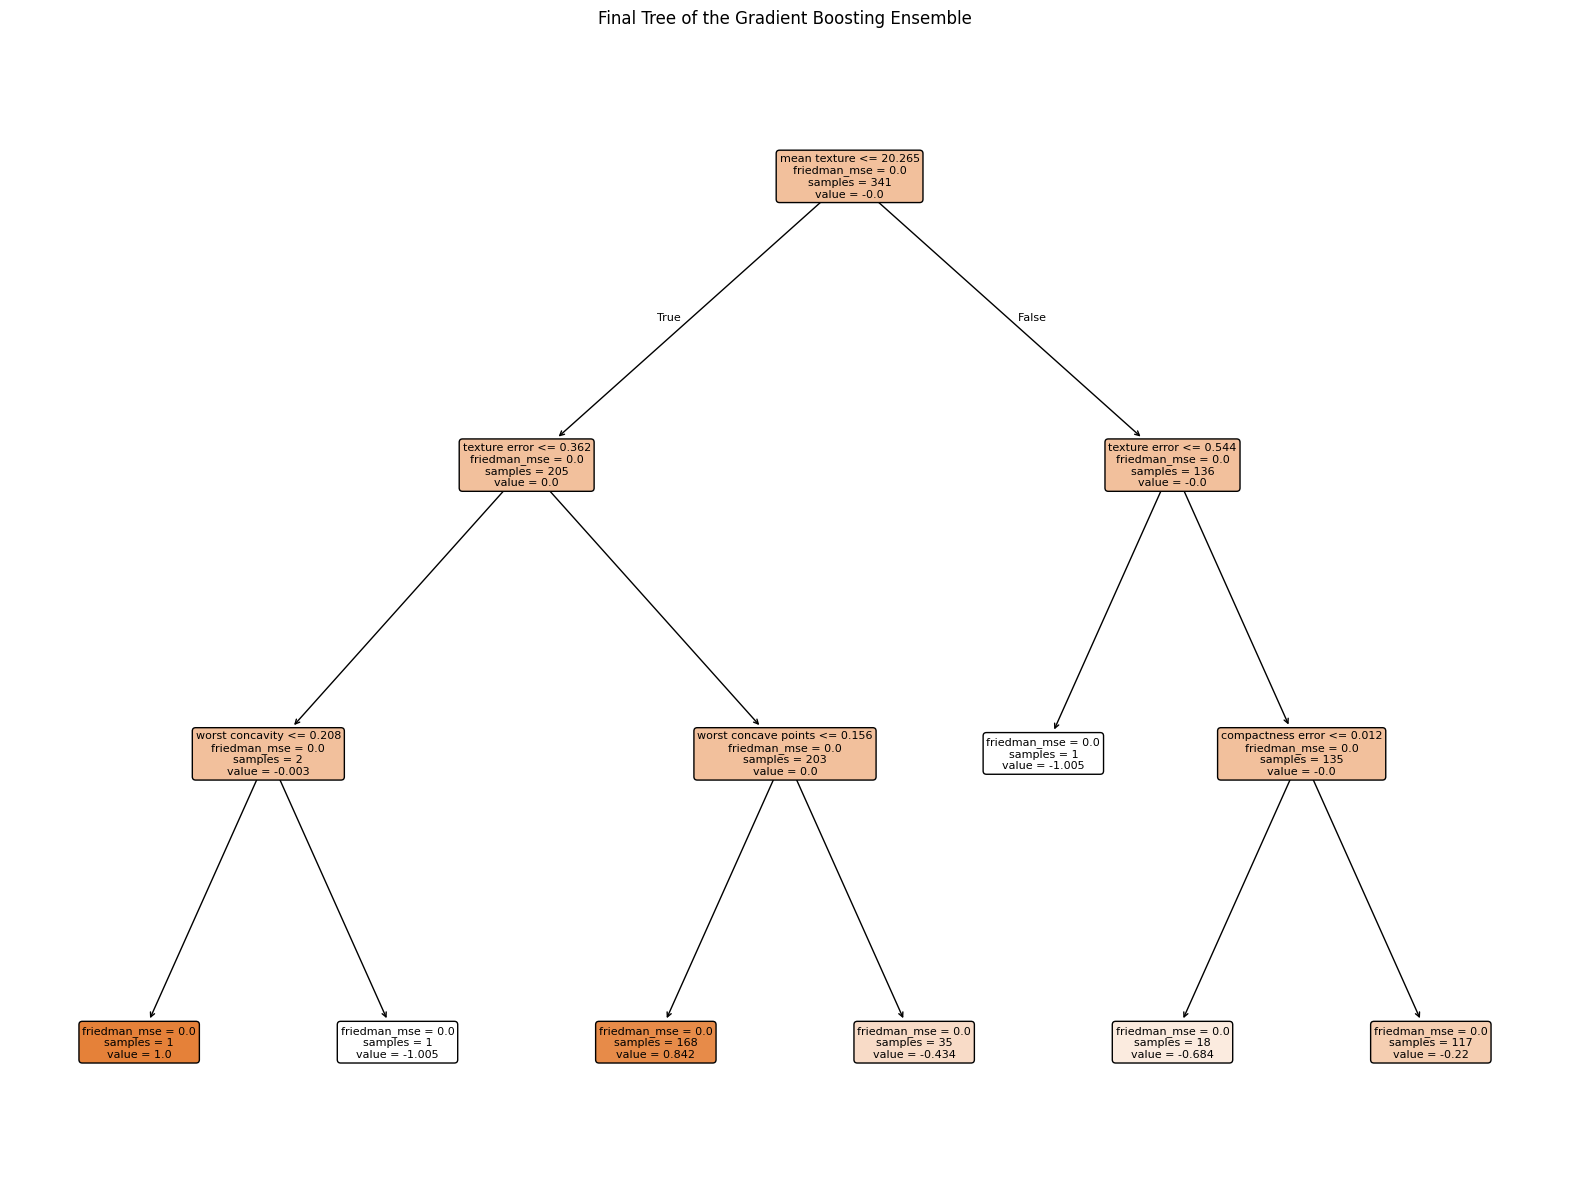

In [6]:
data = load_breast_cancer()
X, y = data.data, data.target

# Split data into training, testing, and validation sets
# 60% training, 20% validation, 20% testing
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=1234
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=1234
)

# Initialize and train the Gradient Boosting model
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=1234) 
model.fit(X_train, y_train)

# Use staged_predict to get predictions on both sets for each iteration
staged_val_predictions = model.staged_predict(X_val)
staged_test_predictions = model.staged_predict(X_test)

print("--- Model Accuracy per Iteration ---")
val_accuracies = []
test_accuracies = []

# Loop through predictions and calculate accuracy
for i, (val_pred, test_pred) in enumerate(zip(staged_val_predictions, staged_test_predictions)):
    val_accuracy = accuracy_score(y_val, val_pred)
    test_accuracy = accuracy_score(y_test, test_pred)
    
    val_accuracies.append(val_accuracy)
    test_accuracies.append(test_accuracy)
    
    print(f"Iteration {i+1}: Validation Accuracy = {val_accuracy:.4f} | Test Accuracy = {test_accuracy:.4f}")

# --- Plot model accuracy ---
# Plotting the accuracy trend
plt.figure(figsize=(12, 8))
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, marker='o', label='Validation Accuracy')
plt.plot(range(1, len(test_accuracies) + 1), test_accuracies, marker='x', linestyle='--', label='Test Accuracy')
plt.title("Model Accuracy per Boosting Iteration", fontsize=16)
plt.xlabel("Number of Estimators", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# Final model evaluation
final_val_accuracy = accuracy_score(y_val, model.predict(X_val))
final_test_accuracy = accuracy_score(y_test, model.predict(X_test))
print(f"\nFinal Validation Accuracy: {final_val_accuracy:.2f}")
print(f"Final Test Accuracy: {final_test_accuracy:.2f}")

# --- Plot final single tree ---
tree = model.estimators_[99, 0]

# Plot the selected tree
plt.figure(figsize=(20, 15))
plot_tree(
    tree,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Final Tree of the Gradient Boosting Ensemble")
plt.show()

- Decision Tree had Model Accuracy of 0.90 for a single tree!
- Let's see the improvement of this model when increasing the number of ensembled trees.

### Custom (from scratch) model
- The purpose of this subtopic is to look at the inner workings of the Gradient Boost.

In [7]:
# This is a Decision Tree for Regression
class DecisionStump:
    """
    A simple one-level decision tree (decision stump) for regression.
    It finds the best split (feature and threshold) to maximize the
    reduction in squared error using the Friedman MSE criterion.
    """
    def __init__(self):
        # The index of the feature used for the split
        self.feature_index = None
        # The value used to split the data
        self.threshold = None
        # The predicted value for data points in the left node (<= threshold)
        self.value_left = None
        # The predicted value for data points in the right node (> threshold)
        self.value_right = None

    def fit(self, X, y):
        """
        Finds the best single split to maximize the Friedman MSE gain.

        Args:
            X (np.ndarray): The input features.
            y (np.ndarray): The target values (or residuals in boosting).
        """
        best_gain = -1
        n_features = X.shape[1]
        
        # Iterate over all features
        for feature_index in range(n_features):
            unique_values = np.unique(X[:, feature_index])
            # Iterate over all unique values as potential thresholds
            for threshold in unique_values:
                # Split the data into two subsets based on the current feature and threshold
                left_indices = X[:, feature_index] <= threshold
                right_indices = X[:, feature_index] > threshold
                
                # Check if the split is valid (not empty)
                if len(y[left_indices]) == 0 or len(y[right_indices]) == 0:
                    continue
                
                # Get the target values for each split
                y_left = y[left_indices]
                y_right = y[right_indices]
                
                # Calculate the predicted values for the left and right nodes
                value_left = np.mean(y_left)
                value_right = np.mean(y_right)
                
                n_left = len(y_left)
                n_right = len(y_right)
                
                # Calculate the gain using the Friedman MSE criterion.
                # The formula is (n_left * n_right) / (n_left + n_right) * (value_left - value_right)^2 
                gain = (n_left * n_right) / (n_left + n_right) * (value_left - value_right)**2

                # If this split is better than the best one found so far, store its parameters
                if gain > best_gain:
                    best_gain = gain
                    self.feature_index = feature_index
                    self.threshold = threshold
                    self.value_left = np.mean(y_left)
                    self.value_right = np.mean(y_right)

    def predict(self, X):
        """
        Predicts the target values for new data.
        """
        predictions = np.zeros(X.shape[0])
        # Make predictions for each data point
        for i, row in enumerate(X):
            if row[self.feature_index] <= self.threshold:
                predictions[i] = self.value_left
            else:
                predictions[i] = self.value_right
        return predictions

In [8]:
# This is the Gradient Boost Regressor
class CustomGradientBoostingRegressor:
    """
    Implementation from scratch of the Gradient Boosting Regressor algorithm.
    It builds an ensemble of DecisionStump weak learners sequentially,
    where each new learner is trained to correct the errors of the
    previous learners.
    """
    def __init__(self, n_estimators=100, learning_rate=0.1):
        """
        Initializes the model with hyperparameters.
        
        Args:
            n_estimators (int): The number of weak learners (trees) to train.
            learning_rate (float): The step size shrinkage to prevent overfitting.
        """
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.trees = []
        # The initial prediction is the average of the target values
        self.initial_prediction = None
        
    def fit(self, X, y):
        """
        Trains the gradient boosting model using DecisionStump as the weak learner.
        
        Args:
            X (np.ndarray): The input features.
            y (np.ndarray): The target values.
        """
        # Step 1: Initialize the model with the average of the target variable
        self.initial_prediction = np.mean(y)
        predictions = np.full(y.shape, self.initial_prediction)
        
        # Step 2: Iterate and train weak learners
        for _ in range(self.n_estimators):
            # Calculate residuals (the negative gradient of the loss function)
            residuals = y - predictions
            
            # Train a new weak learner (Decision Stump) on the residuals
            tree = DecisionStump()
            tree.fit(X, residuals)
            
            # Step 3: Update the predictions with the new tree's output, scaled by the learning rate 
            predictions += self.learning_rate * tree.predict(X)
            
            # Add the new tree to the ensemble
            self.trees.append(tree)
            
    def predict(self, X):
        """
        Makes predictions using the trained model.
        
        Args:
            X (np.ndarray): The input features.
            
        Returns:
            np.ndarray: The predicted values.
        """
        # Start with the initial prediction
        predictions = np.full(X.shape[0], self.initial_prediction)
        
        # Add the weighted predictions from each tree
        for tree in self.trees:
            predictions += self.learning_rate * tree.predict(X)
        
        return predictions
    
    
    def staged_predict(self, X):
        """
        Generates predictions for each boosting iteration.
        
        Args:
            X (np.ndarray): The input features.
            
        Yields:
            np.ndarray: The cumulative predictions after each iteration.
        """
        predictions = np.full(X.shape[0], self.initial_prediction)
        for tree in self.trees:
            predictions += self.learning_rate * tree.predict(X)
            yield predictions

--- Model Accuracy per Iteration ---
Iteration 1: Validation Accuracy = 0.6404 | Test Accuracy = 0.6228
Iteration 2: Validation Accuracy = 0.6404 | Test Accuracy = 0.6228
Iteration 3: Validation Accuracy = 0.8860 | Test Accuracy = 0.8860
Iteration 4: Validation Accuracy = 0.8860 | Test Accuracy = 0.8860
Iteration 5: Validation Accuracy = 0.9035 | Test Accuracy = 0.9035
Iteration 6: Validation Accuracy = 0.8947 | Test Accuracy = 0.8947
Iteration 7: Validation Accuracy = 0.9035 | Test Accuracy = 0.8947
Iteration 8: Validation Accuracy = 0.9035 | Test Accuracy = 0.9035
Iteration 9: Validation Accuracy = 0.8947 | Test Accuracy = 0.9035
Iteration 10: Validation Accuracy = 0.8860 | Test Accuracy = 0.8947
Iteration 11: Validation Accuracy = 0.8947 | Test Accuracy = 0.8947
Iteration 12: Validation Accuracy = 0.8947 | Test Accuracy = 0.9035
Iteration 13: Validation Accuracy = 0.8947 | Test Accuracy = 0.9035
Iteration 14: Validation Accuracy = 0.8860 | Test Accuracy = 0.9035
Iteration 15: Valida

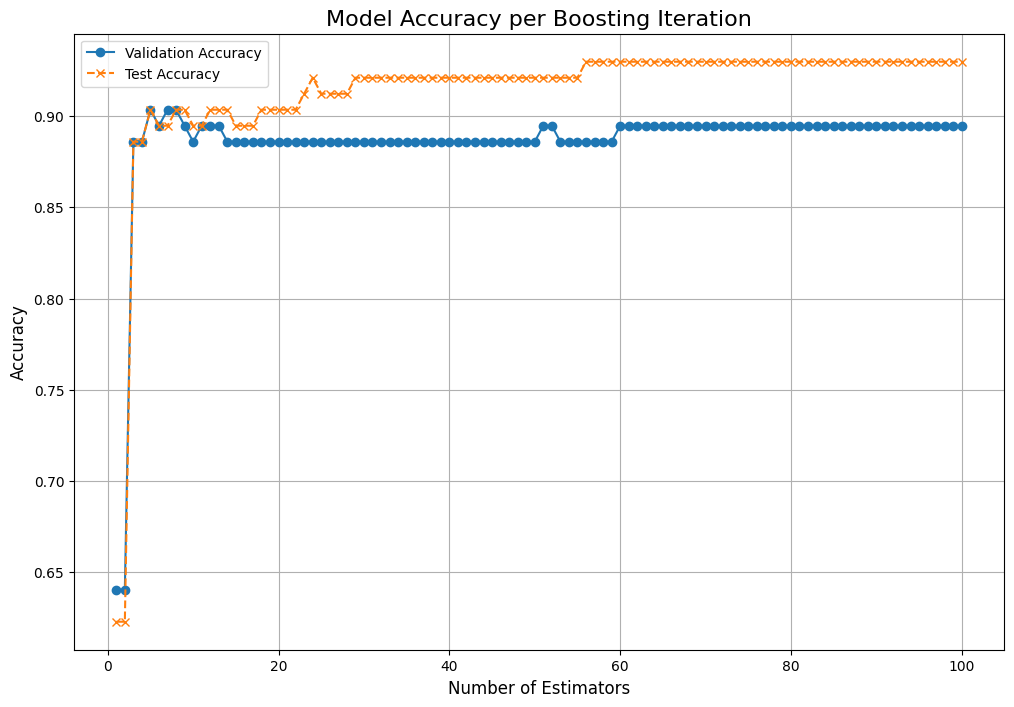


Final Validation Accuracy: 0.89
Final Test Accuracy: 0.93


In [9]:
# Initialize and train the Gradient Boosting model
model = CustomGradientBoostingRegressor(n_estimators=100) 
model.fit(X_train, y_train)

# Use staged_predict to get predictions on both sets for each iteration
staged_val_predictions = model.staged_predict(X_val)
staged_test_predictions = model.staged_predict(X_test)

print("--- Model Accuracy per Iteration ---")
val_accuracies = []
test_accuracies = []

# Loop through predictions and calculate accuracy
for i, (val_pred, test_pred) in enumerate(zip(staged_val_predictions, staged_test_predictions)):
    # Convert regression output to binary classification predictions
    val_pred_binary = (val_pred >= 0.5).astype(int)
    test_pred_binary = (test_pred >= 0.5).astype(int)
    
    val_accuracy = accuracy_score(y_val, val_pred_binary)
    test_accuracy = accuracy_score(y_test, test_pred_binary)
    
    val_accuracies.append(val_accuracy)
    test_accuracies.append(test_accuracy)
    
    print(f"Iteration {i+1}: Validation Accuracy = {val_accuracy:.4f} | Test Accuracy = {test_accuracy:.4f}")

# --- Plot model accuracy ---
# Plotting the accuracy trend
plt.figure(figsize=(12, 8))
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, marker='o', label='Validation Accuracy')
plt.plot(range(1, len(test_accuracies) + 1), test_accuracies, marker='x', linestyle='--', label='Test Accuracy')
plt.title("Model Accuracy per Boosting Iteration", fontsize=16)
plt.xlabel("Number of Estimators", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# Final model evaluation
final_val_pred = model.predict(X_val)
final_val_pred_binary = (final_val_pred >= 0.5).astype(int)
final_test_pred = model.predict(X_test)
final_test_pred_binary = (final_test_pred >= 0.5).astype(int)

final_val_accuracy = accuracy_score(y_val, final_val_pred_binary)
final_test_accuracy = accuracy_score(y_test, final_test_pred_binary)
print(f"\nFinal Validation Accuracy: {final_val_accuracy:.2f}")
print(f"Final Test Accuracy: {final_test_accuracy:.2f}")

---

# 3. Wine Dataset (Complex)

- This is similar to **Decision Tree** notebook's segment. For analysis of data, refer to that notebook. 

In [10]:
ds = load_dataset("lvwerra/red-wine")

train = ds['train']

df = train.to_pandas()

# Separate features and the target variable
features = df.drop('quality', axis=1)
target = df['quality']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

predictor_cols = [col for col in df.columns if col != 'quality']

# Create a new DataFrame with the predictor columns
X = df[predictor_cols]

# Add a constant (intercept) to the DataFrame, which is required for VIF
# The intercept column is automatically named 'const'
X = add_constant(X)

# Calculate VIF for each variable
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

# The VIF is calculated for each variable individually
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Print the VIF values, sorted in descending order
print(vif_data.sort_values(by="VIF", ascending=False))


Repo card metadata block was not found. Setting CardData to empty.


                 feature           VIF
0                  const  1.710538e+06
1          fixed acidity  7.767512e+00
8                density  6.343760e+00
9                     pH  3.329732e+00
3            citric acid  3.128022e+00
11               alcohol  3.031160e+00
7   total sulfur dioxide  2.186813e+00
6    free sulfur dioxide  1.963019e+00
2       volatile acidity  1.789390e+00
4         residual sugar  1.702588e+00
5              chlorides  1.481932e+00
10             sulphates  1.429434e+00


In [11]:
# Initialize and train the Decision Tree model
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=1234)
model.fit(X_train, y_train)

# Evaluate the model (optional, but good practice)
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy:.2f}")
 

Model Accuracy: 0.60


- Increasing n_estimators and depths, simply increases the model accuracy to 0.64. Perhaps with learning rate decay will slightly improve further, but 0.6 is not a good performance, albeit close performance to Random Forest with n_estimator of 100.

---
# Gradient Boost for Regression

--- Model Performance Metrics per Iteration ---


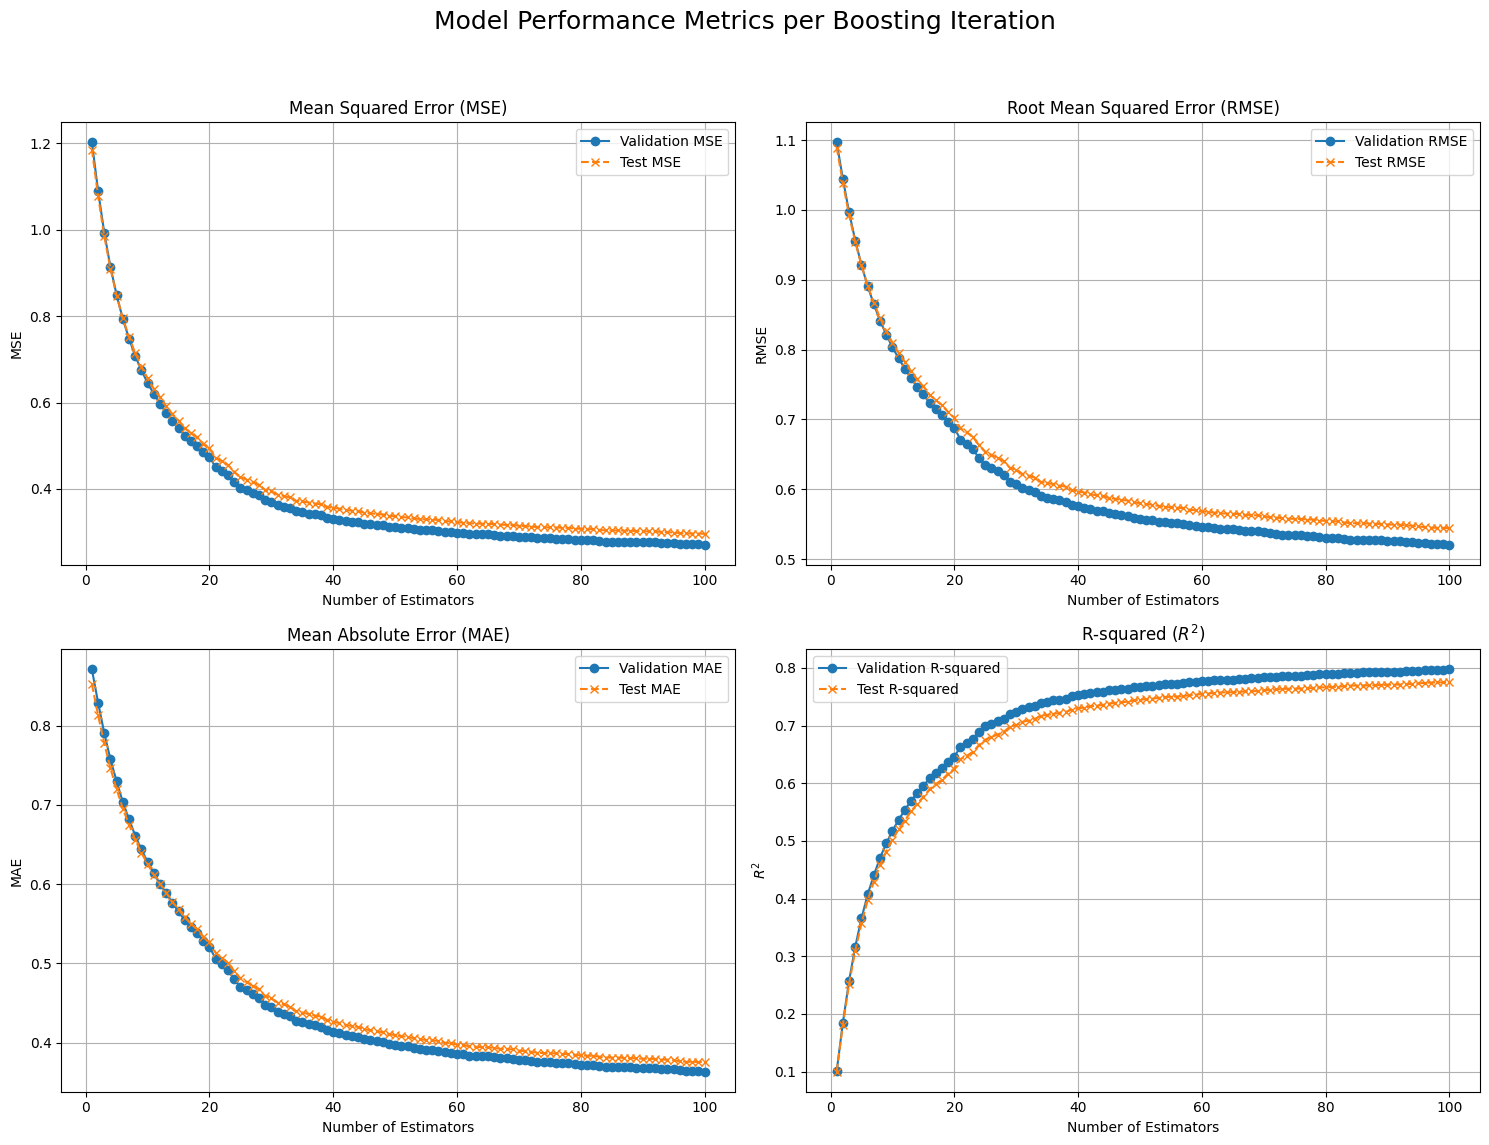

--- Final Model Performance Metrics ---

Final Validation MSE: 0.2713
Final Test MSE: 0.2963
Final Validation RMSE: 0.5209
Final Test RMSE: 0.5443
Final Validation MAE: 0.3634
Final Test MAE: 0.3752
Final Validation R-squared: 0.7972
Final Test R-squared: 0.7752


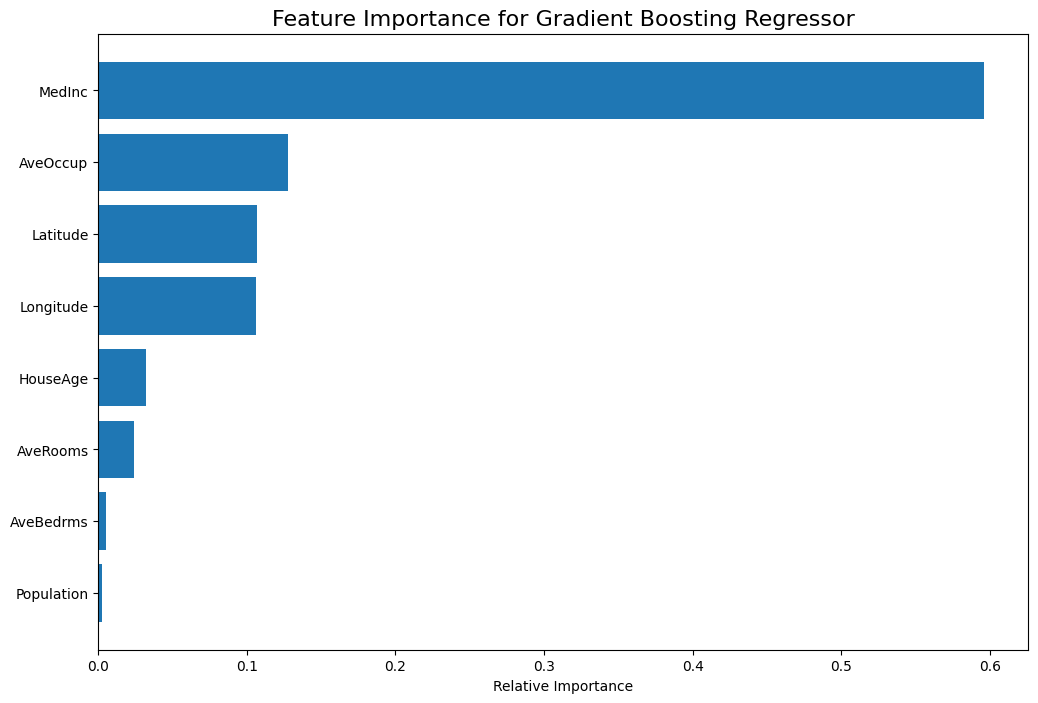

In [12]:
# Load the California housing dataset for regression
data = fetch_california_housing()
X, y = data.data, data.target 
feature_names = data.feature_names # Corrected line to add

# Split data into training, testing, and validation sets
# 60% training, 20% validation, 20% testing
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=1234
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=1234
)

# Initialize and train the Gradient Boosting Regressor model
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=1234)
model.fit(X_train, y_train)

# Use staged_predict to get predictions on both sets for each iteration
staged_val_predictions = model.staged_predict(X_val)
staged_test_predictions = model.staged_predict(X_test)

print("--- Model Performance Metrics per Iteration ---")
val_mses = []
test_mses = []
val_maes = []
test_maes = []
val_r2s = []
test_r2s = []

# Loop through predictions and calculate metrics
for i, (val_pred, test_pred) in enumerate(zip(staged_val_predictions, staged_test_predictions)):
    val_mses.append(mean_squared_error(y_val, val_pred))
    test_mses.append(mean_squared_error(y_test, test_pred))
    val_maes.append(mean_absolute_error(y_val, val_pred))
    test_maes.append(mean_absolute_error(y_test, test_pred))
    val_r2s.append(r2_score(y_val, val_pred))
    test_r2s.append(r2_score(y_test, test_pred))

# Calculate RMSE from MSE
val_rmses = np.sqrt(val_mses)
test_rmses = np.sqrt(test_mses)

# --- Plotting Metrics ---
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
fig.suptitle('Model Performance Metrics per Boosting Iteration', fontsize=18)

# Plot MSE
axes[0, 0].plot(range(1, 101), val_mses, marker='o', label='Validation MSE')
axes[0, 0].plot(range(1, 101), test_mses, marker='x', linestyle='--', label='Test MSE')
axes[0, 0].set_title('Mean Squared Error (MSE)')
axes[0, 0].set_xlabel("Number of Estimators")
axes[0, 0].set_ylabel("MSE")
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot RMSE
axes[0, 1].plot(range(1, 101), val_rmses, marker='o', label='Validation RMSE')
axes[0, 1].plot(range(1, 101), test_rmses, marker='x', linestyle='--', label='Test RMSE')
axes[0, 1].set_title('Root Mean Squared Error (RMSE)')
axes[0, 1].set_xlabel("Number of Estimators")
axes[0, 1].set_ylabel("RMSE")
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot MAE
axes[1, 0].plot(range(1, 101), val_maes, marker='o', label='Validation MAE')
axes[1, 0].plot(range(1, 101), test_maes, marker='x', linestyle='--', label='Test MAE')
axes[1, 0].set_title('Mean Absolute Error (MAE)')
axes[1, 0].set_xlabel("Number of Estimators")
axes[1, 0].set_ylabel("MAE")
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot R2
axes[1, 1].plot(range(1, 101), val_r2s, marker='o', label='Validation R-squared')
axes[1, 1].plot(range(1, 101), test_r2s, marker='x', linestyle='--', label='Test R-squared')
axes[1, 1].set_title('R-squared ($R^2$)')
axes[1, 1].set_xlabel("Number of Estimators")
axes[1, 1].set_ylabel("$R^2$")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Final model evaluation
final_val_pred = model.predict(X_val)
final_test_pred = model.predict(X_test)

final_val_mse = mean_squared_error(y_val, final_val_pred)
final_test_mse = mean_squared_error(y_test, final_test_pred)
final_val_rmse = np.sqrt(final_val_mse)
final_test_rmse = np.sqrt(final_test_mse)
final_val_mae = mean_absolute_error(y_val, final_val_pred)
final_test_mae = mean_absolute_error(y_test, final_test_pred)
final_val_r2 = r2_score(y_val, final_val_pred)
final_test_r2 = r2_score(y_test, final_test_pred)

# --- Print Final Metrics ---
print("--- Final Model Performance Metrics ---")
print(f"\nFinal Validation MSE: {final_val_mse:.4f}")
print(f"Final Test MSE: {final_test_mse:.4f}")
print(f"Final Validation RMSE: {final_val_rmse:.4f}")
print(f"Final Test RMSE: {final_test_rmse:.4f}")
print(f"Final Validation MAE: {final_val_mae:.4f}")
print(f"Final Test MAE: {final_test_mae:.4f}")
print(f"Final Validation R-squared: {final_val_r2:.4f}")
print(f"Final Test R-squared: {final_test_r2:.4f}") 

# --- Plot Feature Importance ---
importances = model.feature_importances_
sorted_indices = np.argsort(importances)

plt.figure(figsize=(12, 8))
plt.barh(range(len(sorted_indices)), importances[sorted_indices], align='center')
plt.yticks(range(len(sorted_indices)), [feature_names[i] for i in sorted_indices])
plt.xlabel('Relative Importance')
plt.title('Feature Importance for Gradient Boosting Regressor', fontsize=16) # Corrected model name
plt.show()

---
# Summary of Gradient Boost
- Training: Sequential (each tree corrects the previous one's errors/loss)
- Ensemble method: Boosting
- Goal: Reduce bias, highly accurate
- Speed: Can be slow due to sequential process
- Robustness: Sensitive to noisy data and outliers
- Overfitting: Prone to overfitting, requires careful tuning
- Interpretability: Less interpretable (each tree is a small piece of a larger puzzle)

---
# Modern implementations of Gradient Boosting
- Extreme Gradient Boosting (XGBoost)
- Light Gradient Boosting Machine (LightGBM)
- Categorical Boosting (CatBoost)

## Summary of comparison

### 1. Tree Growth Strategy 

- **XGBoost (eXtreme Gradient Boosting):** 
    - Uses a **level-wise** (or depth-wise) tree growth strategy. 
    - Builds the tree layer by layer, splitting all nodes at a given level before moving to the next.
    - This approach is more conservative and can lead to a more balanced tree, making it less prone to overfitting than a leaf-wise strategy. 
    - However, it can be slower as it has to evaluate all potential splits at a level.
    

- **LightGBM (Light Gradient Boosting Machine):** 
    - Employs a **leaf-wise** (or best-first) growth strategy. 
    - Grows tree by selecting the leaf with the maximum loss reduction to split. 
    - This can result in a deeper, more complex tree, but it is often much faster as it doesn't waste time on splits that don't significantly reduce the loss. 
    - A potential drawback is that it can overfit on smaller datasets.
    

- **CatBoost (Categorical Boosting):** 
    - Builds **symmetric (oblivious) trees**. 
    - The same feature and split value are used to split nodes at the same level of the tree. 
    - This results in a balanced, symmetric tree, which is a powerful form of regularization that helps prevent overfitting.

### 2. Handling Categorical Features 
- **XGBoost:** 
    - Does **not** handle categorical features natively. 
    - You must preprocess them using techniques like one-hot encoding or label encoding before feeding them to the model.

- **LightGBM:** 
    - Can handle categorical features natively by specifying the columns. 
    - It uses a special algorithm to find the optimal split for categorical features, which is faster and more efficient than one-hot encoding, especially for high-cardinality features.

- **CatBoost:** 
    - Excels at handling categorical features natively. 
    - Uses a unique, sophisticated method called **Ordered Boosting** with a special target-based encoding to convert categorical features to numerical values during training. 
    - This technique prevents **target leakage** and is often considered superior for datasets with many categorical variables.

### 3. Performance & Speed 

- **XGBoost:** 
    - A highly optimized and parallelized implementation of gradient boosting, 
    - significantly faster than traditional Gradient Boosting Machines (GBMs). 
    - _However, it's generally **slower than LightGBM and CatBoost** on large datasets due to its level-wise tree growth and pre-sorting algorithm._

- **LightGBM:** 
    - Known for being **incredibly fast** and efficient. 
    Its speed comes from two main innovations: 
        - a histogram-based algorithm that bins continuous feature values, and 
        - the leaf-wise tree growth strategy. 
    - This makes it an excellent choice for large, high-dimensional datasets.

- **CatBoost:** 
    - Its training speed can be competitive with LightGBM, especially on GPUs. 
    - It is often **faster during prediction** (inference) due to its symmetric tree structure.

### 4. How They Handle Different Task Types
- All three algorithms—**XGBoost**, **LightGBM**, and **CatBoost**—are versatile and can be used for both **regression** and **classification** tasks.
- The suitability of each algorithm for a specific task depends more on the characteristics of the data and the priorities of the project (e.g., speed vs. out-of-the-box performance) rather than its fundamental ability to handle a certain task type.
- Each library provides specific parameters to configure the model for the task at hand. This is typically done by setting the `objective` parameter, which defines the loss function to be minimized.

-  **XGBoost:** 
    - For regression, it uses objectives like `reg:squarederror` (mean squared error). 
    - For classification, it uses `binary:logistic` for binary classification and `multi:softmax` for multi-class classification.
- **LightGBM:** 
    - Similar to XGBoost, it uses objectives 
    - Regression: `regression` or `regression_l1`
    - Classification: `binary` or `multiclass`
- **CatBoost:** 
    - Its objective parameter is straightforward: 
    - Regression: `RMSE`
    - Classification: `Logloss`

---

### Summary and Use Cases

| Feature | XGBoost | LightGBM | CatBoost |
| :--- | :--- | :--- | :--- |
| **Tree Growth** | Level-wise | Leaf-wise | Symmetric (Oblivious) |
| **Categorical Features** | Not native | Native | Native (Excellent) |
| **Training Speed** | Fast, but slowest of the three | **Extremely Fast** | Competitive, can be slower |
| **Overfitting Risk** | Low (with proper tuning) | Higher (on small datasets) | **Lower** (due to design) |
| **Ease of Use** | High tunability, can be complex | Familiar, requires tuning for best results | Excellent defaults, minimal tuning needed |
| **Strengths** | Accuracy, robustness, extensive tuning options | **Speed,** scalability, low memory usage | **Categorical features,** good out-of-the-box performance |
| **When to use** | When you prioritize high accuracy and have time for tuning | When dealing with large datasets and speed is a priority | When your dataset has many categorical features and you want a strong baseline quickly |

## Regression Task

In [13]:
!pip install xgboost lightgbm catboost

--- Training and Evaluating Models ---

Training and evaluating Gradient Boosting...

Training and evaluating XGBoost...

Training and evaluating LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000184 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1837
[LightGBM] [Info] Number of data points in the train set: 12384, number of used features: 8
[LightGBM] [Info] Start training from score 2.064254
Note: Per-iteration plots are only generated for Gradient Boosting and XGBoost.

Training and evaluating CatBoost...


/home/troll/miniconda3/envs/random/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/troll/miniconda3/envs/random/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Note: Per-iteration plots are only generated for Gradient Boosting and XGBoost.


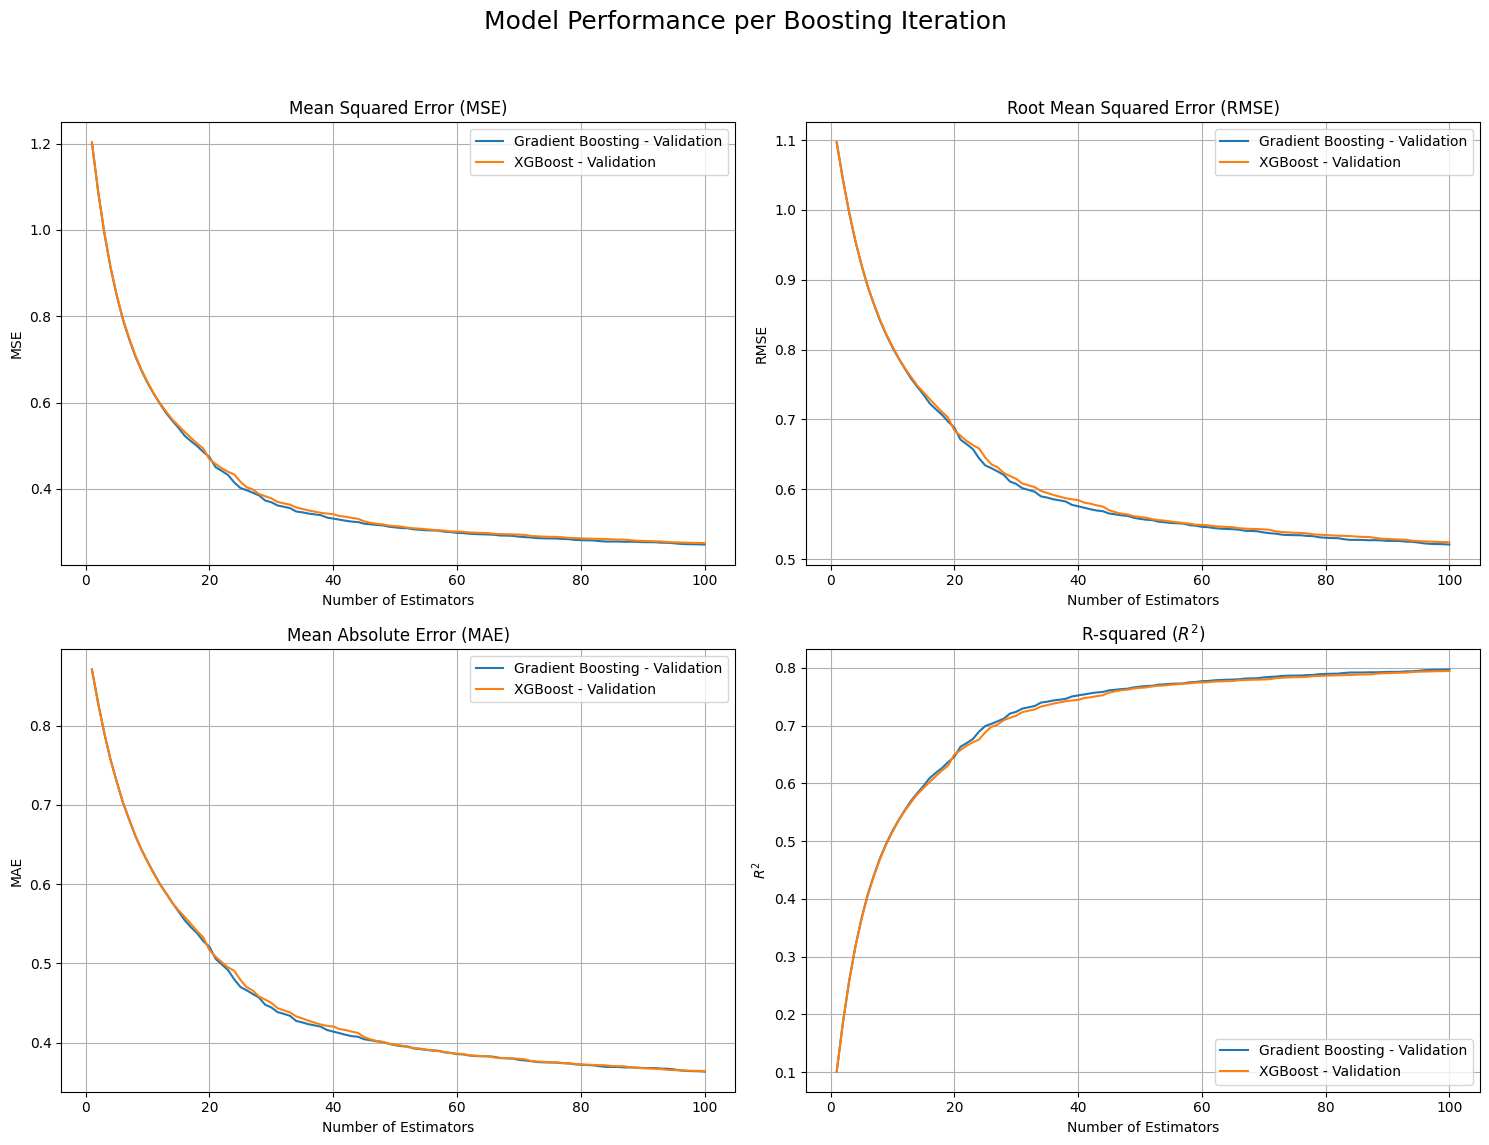


--- Final Model Performance Metrics ---

--- Gradient Boosting ---
Final Validation MSE: 0.2713
Final Test MSE: 0.2963
Final Validation RMSE: 0.5209
Final Test RMSE: 0.5443
Final Validation MAE: 0.3634
Final Test MAE: 0.3752
Final Validation R-squared: 0.7972
Final Test R-squared: 0.7752

--- XGBoost ---
Final Validation MSE: 0.2747
Final Test MSE: 0.2987
Final Validation RMSE: 0.5241
Final Test RMSE: 0.5465
Final Validation MAE: 0.3642
Final Test MAE: 0.3753
Final Validation R-squared: 0.7947
Final Test R-squared: 0.7733

--- LightGBM ---
Final Validation MSE: 0.2153
Final Test MSE: 0.2399
Final Validation RMSE: 0.4640
Final Test RMSE: 0.4898
Final Validation MAE: 0.3099
Final Test MAE: 0.3244
Final Validation R-squared: 0.8391
Final Test R-squared: 0.8180

--- CatBoost ---
Final Validation MSE: 0.2500
Final Test MSE: 0.2776
Final Validation RMSE: 0.5000
Final Test RMSE: 0.5269
Final Validation MAE: 0.3469
Final Test MAE: 0.3592
Final Validation R-squared: 0.8131
Final Test R-squared

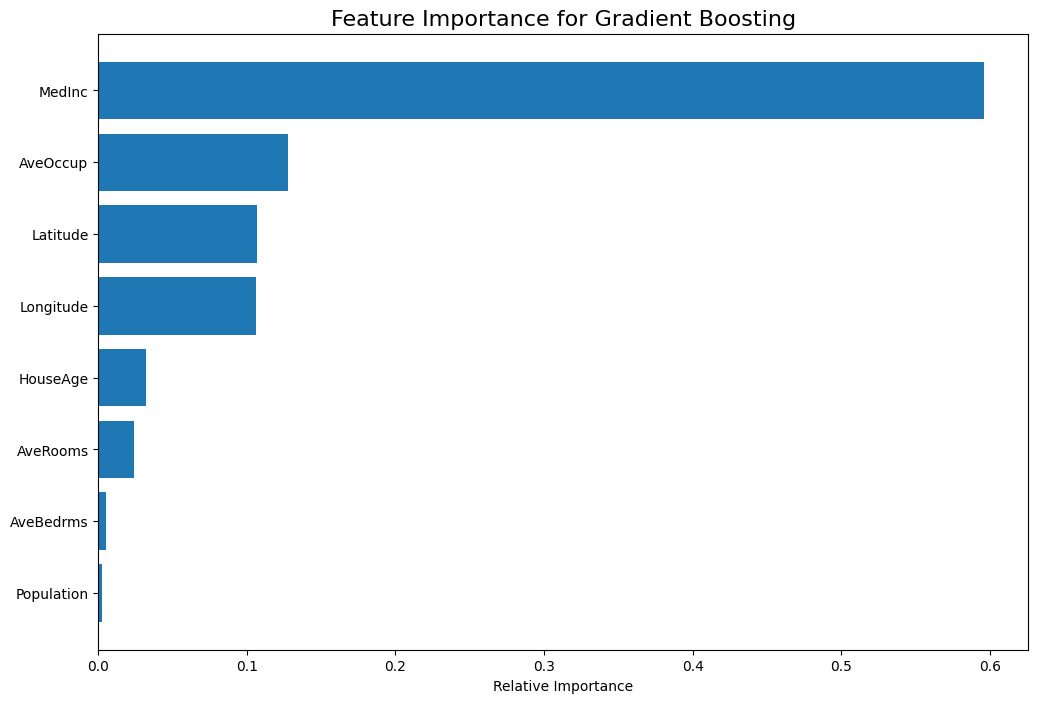

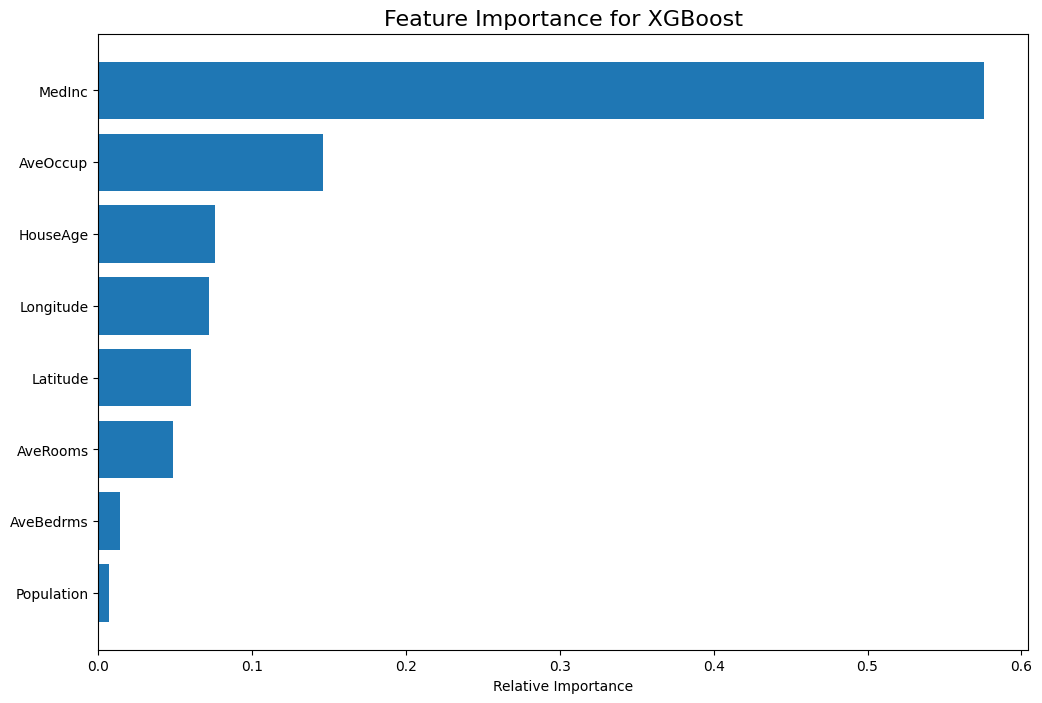

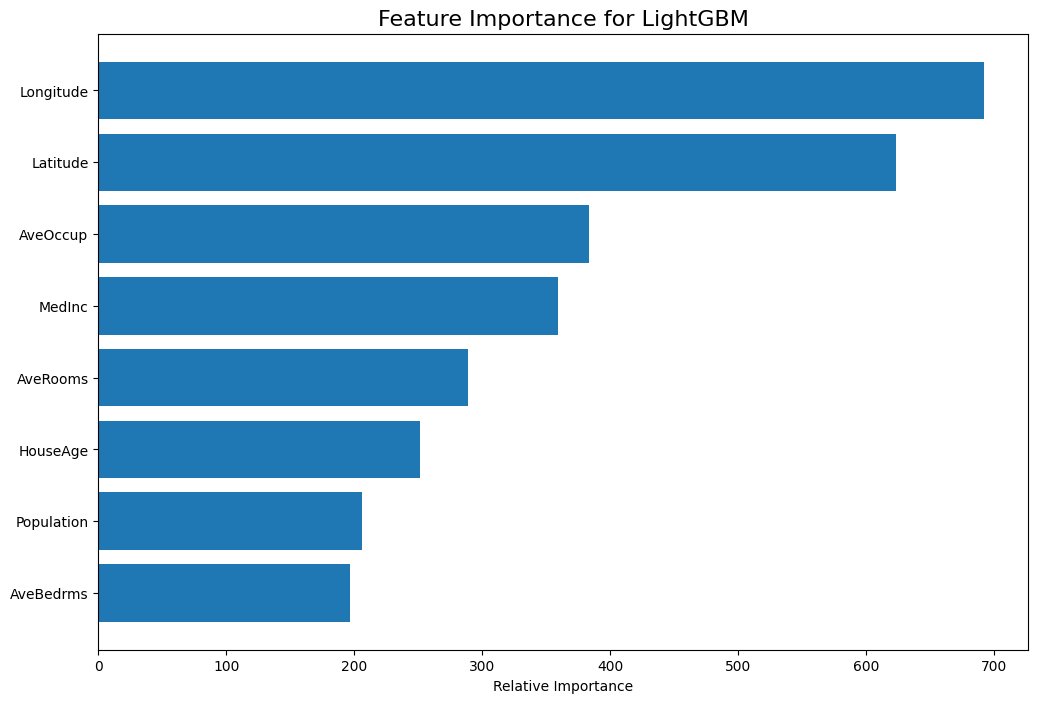

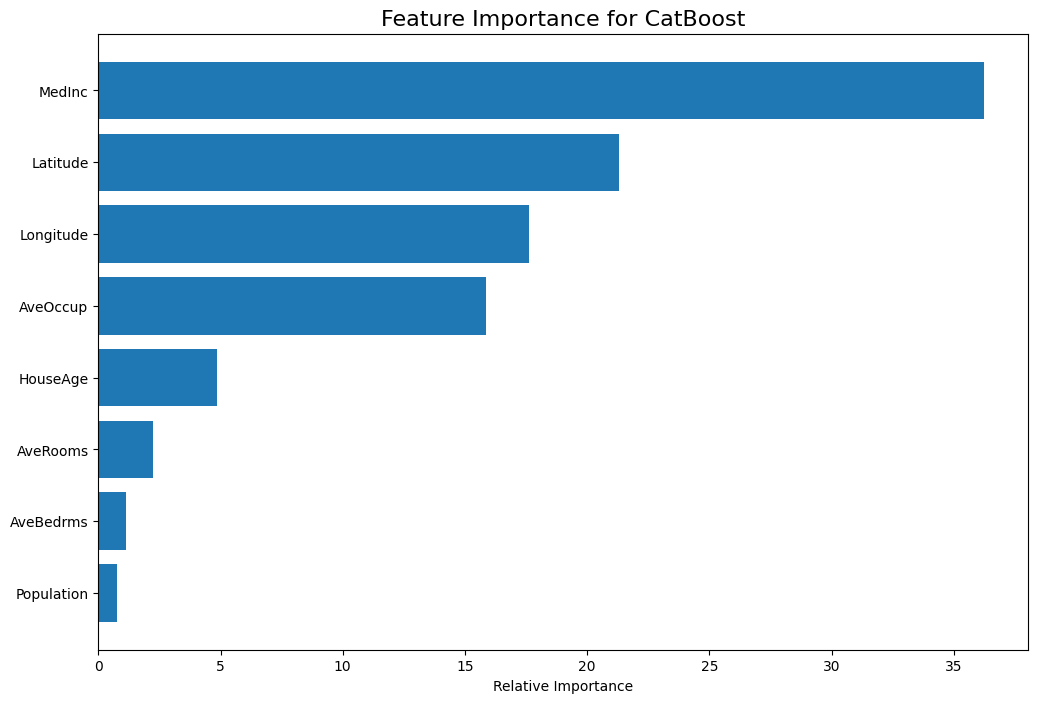

In [14]:
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# Load the California housing dataset for regression
data = fetch_california_housing()
X, y = data.data, data.target
feature_names = data.feature_names

# Split data into training, testing, and validation sets
# 60% training, 20% validation, 20% testing
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=1234
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=1234
)

# --- Model Definitions ---
# Define the models with similar parameters for fair comparison
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=1234),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=1234, eval_metric='rmse'),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, num_leaves=31, random_state=1234),
    'CatBoost': cb.CatBoostRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=1234, verbose=0)
}

# --- Main Comparison Loop ---
# This dictionary will store all metrics for all models
metrics_by_model = {name: {'val_mses': [], 'test_mses': [], 'val_maes': [], 'test_maes': [], 'val_r2s': [], 'test_r2s': []} for name in models.keys()}
final_metrics = {name: {} for name in models.keys()}

print("--- Training and Evaluating Models ---")
for name, model in models.items():
    print(f"\nTraining and evaluating {name}...")

    # Train the model with the updated API
    if name == 'CatBoost':
        model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=10, verbose=0)
    elif name == 'LightGBM':
        # Corrected: Use callbacks for early stopping in modern LightGBM
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)])
    else: # Gradient Boosting and XGBoost
        model.fit(X_train, y_train)

    # Calculate per-iteration predictions for models that support it
    if name == 'Gradient Boosting':
        staged_val_predictions = model.staged_predict(X_val)
        staged_test_predictions = model.staged_predict(X_test)
        
        for val_pred, test_pred in zip(staged_val_predictions, staged_test_predictions):
            metrics_by_model[name]['val_mses'].append(mean_squared_error(y_val, val_pred))
            metrics_by_model[name]['test_mses'].append(mean_squared_error(y_test, test_pred))
            metrics_by_model[name]['val_maes'].append(mean_absolute_error(y_val, val_pred))
            metrics_by_model[name]['test_maes'].append(mean_absolute_error(y_test, test_pred))
            metrics_by_model[name]['val_r2s'].append(r2_score(y_val, val_pred))
            metrics_by_model[name]['test_r2s'].append(r2_score(y_test, test_pred))

    elif name == 'XGBoost':
        n_estimators = model.get_booster().best_iteration + 1 if hasattr(model, 'best_iteration') and model.get_booster().best_iteration > 0 else model.n_estimators
        for i in range(1, n_estimators + 1):
            val_pred = model.predict(X_val, iteration_range=(0, i))
            test_pred = model.predict(X_test, iteration_range=(0, i))
            
            metrics_by_model[name]['val_mses'].append(mean_squared_error(y_val, val_pred))
            metrics_by_model[name]['test_mses'].append(mean_squared_error(y_test, test_pred))
            metrics_by_model[name]['val_maes'].append(mean_absolute_error(y_val, val_pred))
            metrics_by_model[name]['test_maes'].append(mean_absolute_error(y_test, test_pred))
            metrics_by_model[name]['val_r2s'].append(r2_score(y_val, val_pred))
            metrics_by_model[name]['test_r2s'].append(r2_score(y_test, test_pred))

    else: # LightGBM and CatBoost
        val_pred = model.predict(X_val)
        test_pred = model.predict(X_test)
        
        final_metrics[name]['val_mse'] = mean_squared_error(y_val, val_pred)
        final_metrics[name]['test_mse'] = mean_squared_error(y_test, test_pred)
        final_metrics[name]['val_mae'] = mean_absolute_error(y_val, val_pred)
        final_metrics[name]['test_mae'] = mean_absolute_error(y_test, test_pred)
        final_metrics[name]['val_r2'] = r2_score(y_val, val_pred)
        final_metrics[name]['test_r2'] = r2_score(y_test, test_pred)
        print(f"Note: Per-iteration plots are only generated for Gradient Boosting and XGBoost.")

# --- Plotting Metrics per Iteration for Supported Models ---
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
fig.suptitle('Model Performance per Boosting Iteration', fontsize=18)

for name, metrics in metrics_by_model.items():
    if not metrics['val_mses']:
        continue
        
    val_rmses = np.sqrt(metrics['val_mses'])
    n_estimators = len(metrics['val_mses'])
    
    axes[0, 0].plot(range(1, n_estimators + 1), metrics['val_mses'], label=f'{name} - Validation')
    axes[0, 1].plot(range(1, n_estimators + 1), val_rmses, label=f'{name} - Validation')
    axes[1, 0].plot(range(1, n_estimators + 1), metrics['val_maes'], label=f'{name} - Validation')
    axes[1, 1].plot(range(1, n_estimators + 1), metrics['val_r2s'], label=f'{name} - Validation')

axes[0, 0].set_title('Mean Squared Error (MSE)')
axes[0, 1].set_title('Root Mean Squared Error (RMSE)')
axes[1, 0].set_title('Mean Absolute Error (MAE)')
axes[1, 1].set_title('R-squared ($R^2$)')

for ax in axes.flatten():
    ax.set_xlabel("Number of Estimators")
    ax.grid(True)
    ax.legend()

axes[0, 0].set_ylabel("MSE")
axes[0, 1].set_ylabel("RMSE")
axes[1, 0].set_ylabel("MAE")
axes[1, 1].set_ylabel("$R^2$")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Print Final Metrics for All Models ---
print("\n--- Final Model Performance Metrics ---")
for name in models.keys():
    print(f"\n--- {name} ---")
    
    if name in metrics_by_model and metrics_by_model[name]['val_mses']:
        final_val_mse = metrics_by_model[name]['val_mses'][-1]
        final_test_mse = metrics_by_model[name]['test_mses'][-1]
    elif name in final_metrics:
        final_val_mse = final_metrics[name]['val_mse']
        final_test_mse = final_metrics[name]['test_mse']
    
    final_val_rmse = np.sqrt(final_val_mse)
    final_test_rmse = np.sqrt(final_test_mse)
    
    if name in metrics_by_model and metrics_by_model[name]['val_maes']:
        final_val_mae = metrics_by_model[name]['val_maes'][-1]
        final_test_mae = metrics_by_model[name]['test_maes'][-1]
        final_val_r2 = metrics_by_model[name]['val_r2s'][-1]
        final_test_r2 = metrics_by_model[name]['test_r2s'][-1]
    elif name in final_metrics:
        final_val_mae = final_metrics[name]['val_mae']
        final_test_mae = final_metrics[name]['test_mae']
        final_val_r2 = final_metrics[name]['val_r2']
        final_test_r2 = final_metrics[name]['test_r2']

    print(f"Final Validation MSE: {final_val_mse:.4f}")
    print(f"Final Test MSE: {final_test_mse:.4f}")
    print(f"Final Validation RMSE: {final_val_rmse:.4f}")
    print(f"Final Test RMSE: {final_test_rmse:.4f}")
    print(f"Final Validation MAE: {final_val_mae:.4f}")
    print(f"Final Test MAE: {final_test_mae:.4f}")
    print(f"Final Validation R-squared: {final_val_r2:.4f}")
    print(f"Final Test R-squared: {final_test_r2:.4f}")

# --- Plot Feature Importance for All Models ---
for name, model in models.items():
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        sorted_indices = np.argsort(importances)
        
        plt.figure(figsize=(12, 8))
        plt.barh(range(len(sorted_indices)), importances[sorted_indices], align='center')
        plt.yticks(range(len(sorted_indices)), [feature_names[i] for i in sorted_indices])
        plt.xlabel('Relative Importance')
        plt.title(f'Feature Importance for {name}', fontsize=16)
        plt.show()

---

### Note 1: Performance

Based on the final performance metrics, **LightGBM** is the best-performing model for this California housing dataset.
 
#### Best Model Performance
- LightGBM consistently outperforms the other models across all key metrics on both the validation and test datasets.

- **Lowest Error:** 
    - LightGBM has the lowest **Mean Squared Error (MSE)**, **Root Mean Squared Error (RMSE)**, and **Mean Absolute Error (MAE)**. 
    - For instance, its Test RMSE of **0.4898** is significantly lower than the next best, CatBoost's 0.5269. 
    - A lower error score means the model's predictions are closer to the actual values.

- **Highest $R^2$ Score:** 
    - LightGBM also achieved the highest **R-squared ($R^2$) score** at **0.8180** on the test set. 
    - The $R^2$ score represents the proportion of the variance in the dependent variable that's predictable from the independent variables. An $R^2$ of 0.8180 indicates that the model explains about 81.8% of the variability in the housing prices, which is the best among the four models.

#### Model Ranking
Based on the provided metrics, the models can be ranked from best to worst:
1.  **LightGBM**: Clear winner with the lowest error and highest $R^2$.
2.  **CatBoost**: Second best, with lower error and higher $R^2$ than the scikit-learn and XGBoost models.
3.  **Gradient Boosting**: Performs slightly better than XGBoost on most metrics.
4.  **XGBoost**: The lowest-performing model in this comparison, with the highest error scores and lowest $R^2$.

---
### Note 2:


- Per-iteration plots are only generated for Gradient Boosting and XGBoost because these models expose a specific method to retrieve predictions for each boosting iteration, while LightGBM and CatBoost do not offer the same functionality in their standard API.
- **Gradient Boosting (scikit-learn)**: 
    - This library's GradientBoostingRegressor model provides a method called .staged_predict(). 
    - This is an explicit iterator that yields predictions after each individual tree is added to the ensemble. 
    - _This design makes it simple to plot the validation and test metrics at every step of the boosting process._
- **XGBoost**: 
    - The XGBoost library also provides a way to get per-iteration predictions, although the method has evolved. 
    - You can use the .predict() method with the iteration_range parameter to specify a range of trees (e.g., from tree 0 to tree i) to make predictions with. 
    - By looping through the number of estimators, you can manually simulate the staged prediction process.
- **LightGBM** and **CatBoost** 
    - These libraries are designed for speed and efficiency. 
    - Their public APIs do not include a built-in `staged_predict method` or an equivalent parameter to easily get predictions for each boosting round. 
    - While they offer callbacks and evaluation sets for internal early stopping, this process is optimized for training and doesn't provide a convenient way to access intermediate predictions for external plotting. 
    - For these models, you typically only get the final prediction after the entire training process is complete.